# Duplicate Videos

This notebook explores how duplicate videos are distributed in the dataset.

In [28]:
import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from utils.dataset import DataSet

Define the paths used to access data and metadata.

In [29]:
# data folder
folder_data = repo_root / 'data'

# metadata folder
folder_meta = repo_root / 'metadata'

# mice/recording folders
all_recording_folders = [
    'dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29515-10-12-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29623-4-9-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20',
]


Initialize a `DataSet` object to handle the full dataset.

In [30]:
# Inizialize and object from DataSet to handle the dataset
ds = DataSet(folder_data, 
             folder_metadata=folder_meta,
             recording=all_recording_folders, 
             verbose=True)

# Load the metadat for all triasls
trials_df = ds.get_trials_metadata()

# Mapping from recording name to rec-animalID-session-scan format
mapping = {}
for rec in ds.recording:
    x = rec.split("-")
    mapping[rec] = f"rec-{ds.info[rec]['animal_id']}-{ds.info[rec]['session']}-{ds.info[rec]['scan_idx']}"


Initializing DataSet -------------------------------------------------------------------------------

Checking the data ----------------------------------------------------------------------------------
- All data files seem consistent across trials and data types for recording dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce.
- All data files seem consistent across trials and data types for recording dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce.
- All data files seem consistent across trials and data types for recording dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce.
- All data files seem consistent across trials and data types for recording dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce.
- All data files seem consistent across trials and data types for recording dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce.
- All data files seem consistent across trials and data types for recording dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9628efe

## Duplicates across recordings

Check whether videos are repeated across different recordings.

Videos appearing in more than 1 unique recording: 1895 out of 1987 unique videos


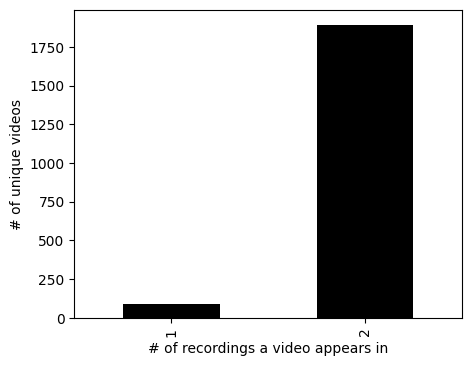

In [ ]:
n_unique_videos = trials_df['ID'].nunique()

# Find the videos repeated across recordings
counts = ds.count_videos_across(['recording','label','ID'])

# Find IDs that have more than 1 unique recording
count_recordings_x_videoid = counts.groupby('ID')['recording'].nunique()
ids_with_diff_recordings = count_recordings_x_videoid[count_recordings_x_videoid > 1].index
print(f"Videos appearing in more than 1 unique recording: {len(ids_with_diff_recordings.to_list())} out of {n_unique_videos} unique videos")

# Plot an histogram with the number of unique videos appearing in n recordings
fig, ax = plt.subplots(figsize=(5, 4))
count_recordings_x_videoid.value_counts().sort_index().plot(kind='bar', ax=ax, color='black')
ax.set_xlabel("# of recordings a video appears in")
ax.set_ylabel("# of unique videos")
fig.savefig(Path(repo_root, 'figures', f'count-video-duplicates_n-recordings.png'))

### Videos appearing in 1 recording

Plot for the videos appearing in 1 recording, 
- how they are distributed across recordings
- how they are distributed across labels
- how they are ditributed for each label across recordings


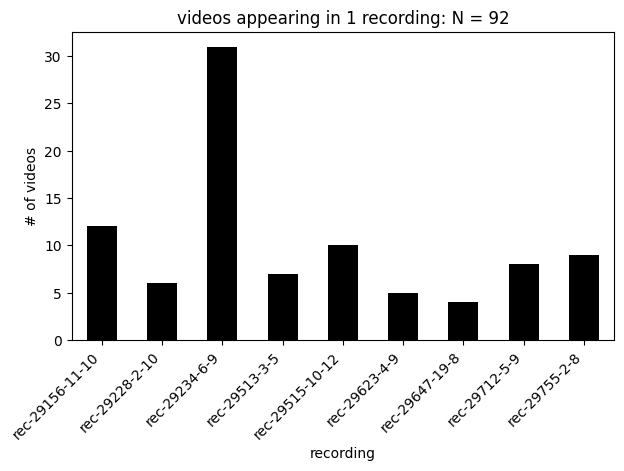

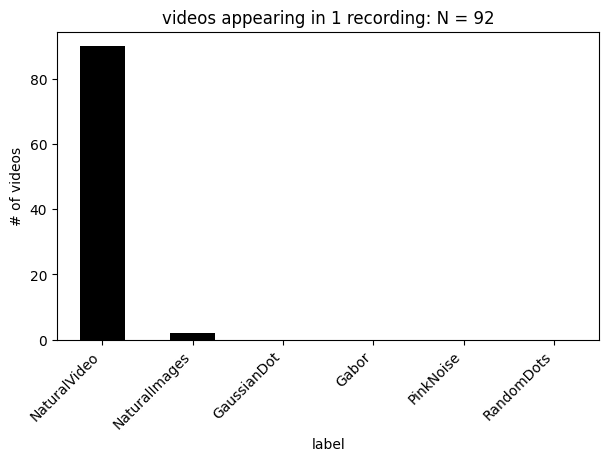

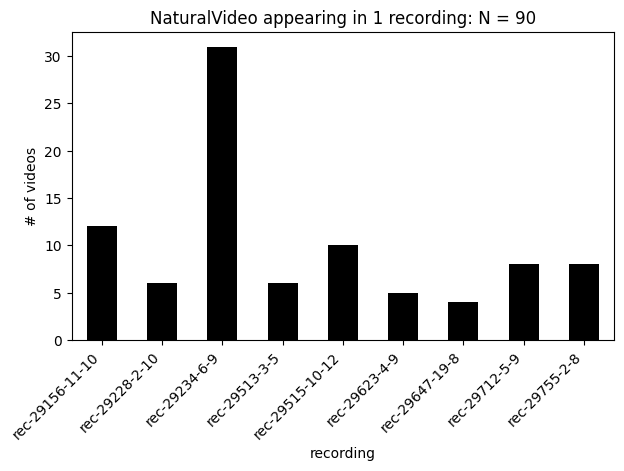

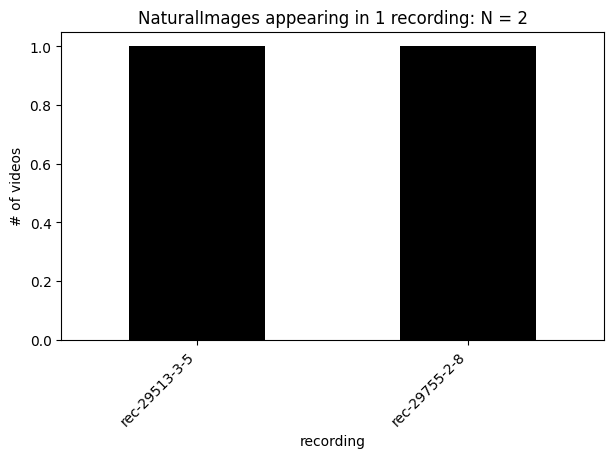

In [77]:
ordered_labels = ['NaturalVideo','NaturalImages','GaussianDot','Gabor','PinkNoise','RandomDots']

# Find the videos IDs that appear in only 1 unique recording and count the number of unique videos appearing in each recording among those
ids_1_recordings = count_recordings_x_videoid[count_recordings_x_videoid == 1].index
trials_df_1_recording = trials_df[trials_df['ID'].isin(ids_1_recordings)]

# Plot
count_ids_x_recording = trials_df_1_recording.groupby('recording')['ID'].nunique()
fig, ax = plt.subplots(figsize=(7, 4))
count_ids_x_recording.plot(kind='bar', ax=ax, color='black')
ax.set_xlabel("recording")
ax.set_ylabel("# of videos")
ax.set_title(f"videos appearing in 1 recording: N = {len(ids_1_recordings)}")
_ = ax.set_xticklabels([mapping[rec] for rec in count_ids_x_recording.index], rotation=45, ha='right')
fig.savefig(Path(repo_root, 'figures', f'count-video-duplicates_in-1-recording_by-recording.png'))

# Plot by label
count_ids_x_label = trials_df_1_recording.groupby('label')['ID'].nunique()
count_ids_x_label = count_ids_x_label.reindex(ordered_labels)
fig, ax = plt.subplots(figsize=(7, 4))
count_ids_x_label.plot(kind='bar', ax=ax, color='black')
ax.set_xlabel("label")
ax.set_ylabel("# of videos")
ax.set_title(f"videos appearing in 1 recording: N = {len(ids_1_recordings)}")
_ = ax.set_xticklabels(count_ids_x_label.index, rotation=45, ha='right')
fig.savefig(Path(repo_root, 'figures', f'count-video-duplicates_in-1-recording_by-label.png'))

# Do it per labels per recording
for lab in ordered_labels:
    count_ids_x_recording_lab = trials_df_1_recording[trials_df_1_recording['label'] == lab].groupby('recording')['ID'].nunique()
    n = len(trials_df_1_recording[trials_df_1_recording['label'] == lab].groupby('ID'))
    if len(count_ids_x_recording_lab)>0:
        fig, ax = plt.subplots(figsize=(7, 4))
        count_ids_x_recording_lab.plot(kind='bar', ax=ax, color='black')
        ax.set_xlabel("recording")
        ax.set_ylabel("# of videos")
        ax.set_title(f"{lab} appearing in 1 recording: N = {n}")
        _ = ax.set_xticklabels([mapping[rec] for rec in count_ids_x_recording_lab.index], rotation=45, ha='right')
        fig.savefig(Path(repo_root, 'figures', f'count-video-duplicates_in-1-recording_by-recording-{lab}.png'))


Print the two videos belonging to NatutalImages and appearing in only one recording

They correspond to the videos with bad properties

In [57]:
trials_df_1_recording[trials_df_1_recording['label'] == 'NaturalImages']

,recording,label,ID,trial,trial_type,valid_frames,valid_trial
2420,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v565001,668,train,403,False
6591,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v731584,156,live_test_main,414,False


### Videos appearing in 2 recordings

Plot for the videos appearing in 2 recording, 
- how they are distributed across recordings
- how they are distributed across labels
- how they are ditributed for each label across recordings

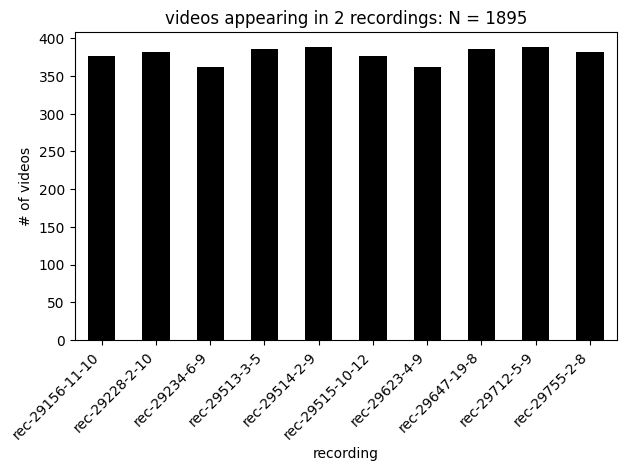

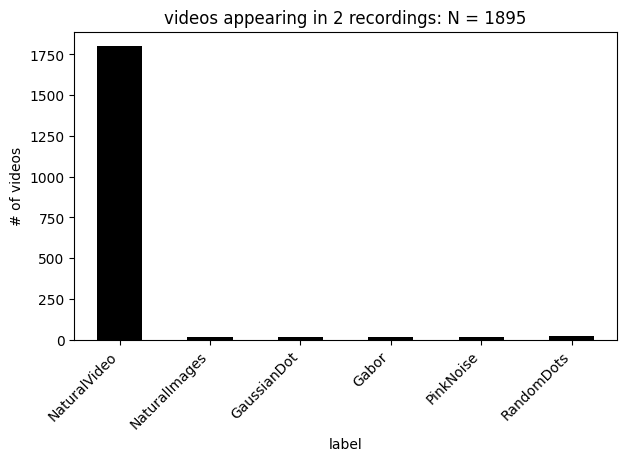

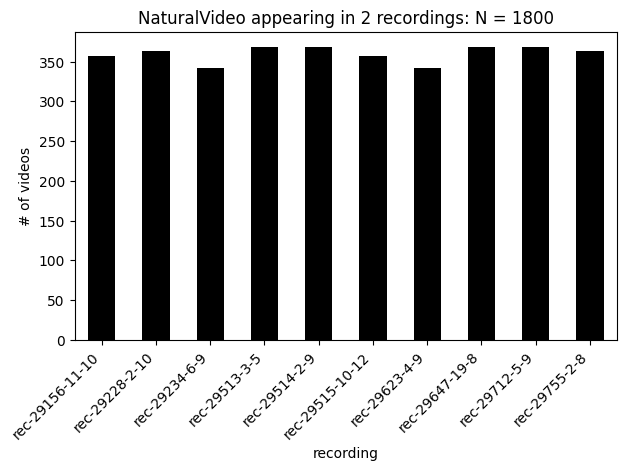

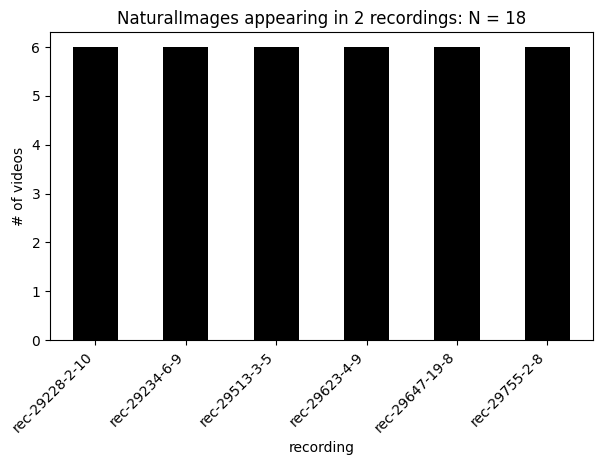

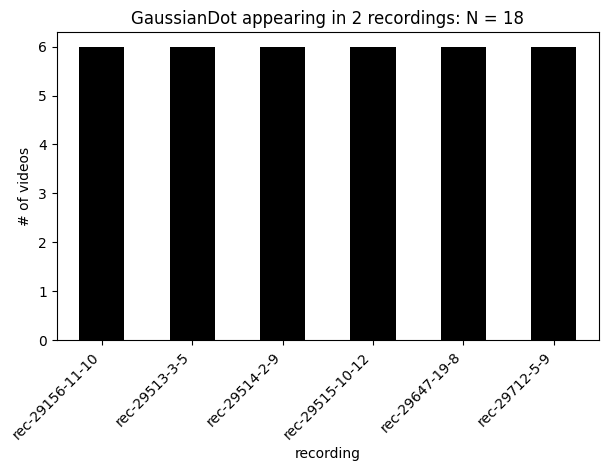

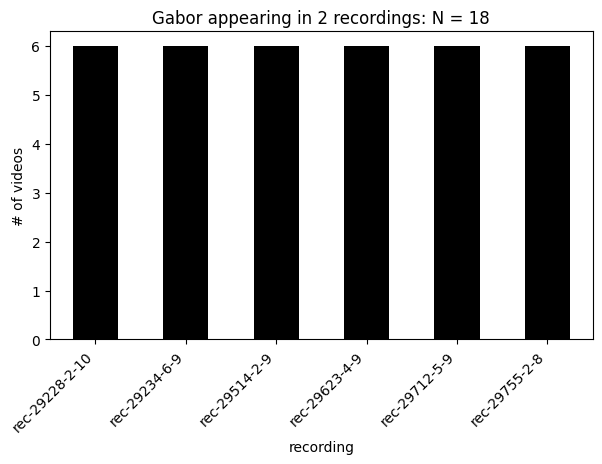

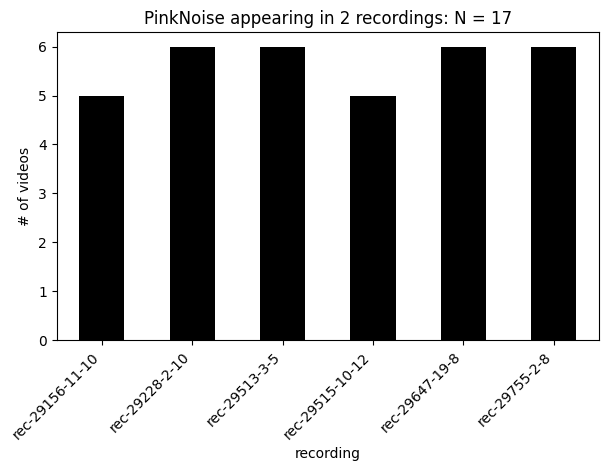

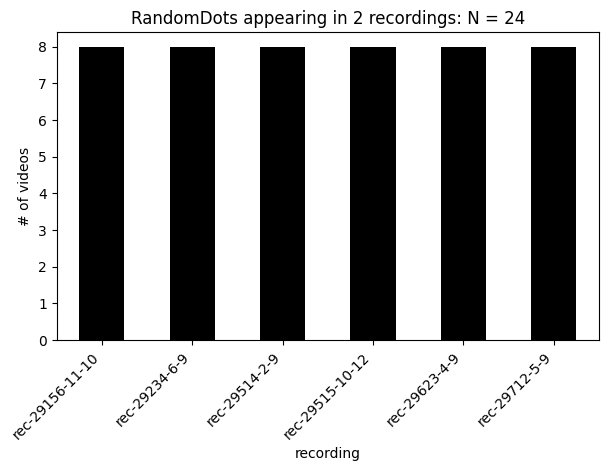

In [78]:
ordered_labels = ['NaturalVideo','NaturalImages','GaussianDot','Gabor','PinkNoise','RandomDots']

# Find the videos IDs that appear in 2 unique recording and count the number of unique videos appearing in each recording among those
ids_2_recordings = count_recordings_x_videoid[count_recordings_x_videoid == 2].index
trials_df_2_recording = trials_df[trials_df['ID'].isin(ids_2_recordings)]

# Plot
count_ids_x_recording = trials_df_2_recording.groupby('recording')['ID'].nunique()
fig, ax = plt.subplots(figsize=(7, 4))
count_ids_x_recording.plot(kind='bar', ax=ax, color='black')
ax.set_xlabel("recording")
ax.set_ylabel("# of videos")
ax.set_title(f"videos appearing in 2 recordings: N = {len(ids_2_recordings)}")
_ = ax.set_xticklabels([mapping[rec] for rec in count_ids_x_recording.index], rotation=45, ha='right')
fig.savefig(Path(repo_root, 'figures', f'count-video-duplicates_in-2-recordings_by-recording.png'))

# Plot by label
count_ids_x_label = trials_df_2_recording.groupby('label')['ID'].nunique()
count_ids_x_label = count_ids_x_label.reindex(ordered_labels)
fig, ax = plt.subplots(figsize=(7, 4))
count_ids_x_label.plot(kind='bar', ax=ax, color='black')
ax.set_xlabel("label")
ax.set_ylabel("# of videos")
ax.set_title(f"videos appearing in 2 recordings: N = {len(ids_2_recordings)}")
_ = ax.set_xticklabels(count_ids_x_label.index, rotation=45, ha='right')
fig.savefig(Path(repo_root, 'figures', f'count-video-duplicates_in-2-recordings_by-label.png'))

# Do it per labels per recording
for lab in ordered_labels:
    count_ids_x_recording_lab = trials_df_2_recording[trials_df_2_recording['label'] == lab].groupby('recording')['ID'].nunique()
    n = len(trials_df_2_recording[trials_df_2_recording['label'] == lab].groupby('ID'))
    if len(count_ids_x_recording_lab)>0:
        fig, ax = plt.subplots(figsize=(7, 4))
        count_ids_x_recording_lab.plot(kind='bar', ax=ax, color='black')
        ax.set_xlabel("recording")
        ax.set_ylabel("# of videos")
        ax.set_title(f"{lab} appearing in 2 recordings: N = {n}")
        _ = ax.set_xticklabels([mapping[rec] for rec in count_ids_x_recording_lab.index], rotation=45, ha='right')
        fig.savefig(Path(repo_root, 'figures', f'count-video-duplicates_in-2-recordings_by-recording-{lab}.png'))


## Replicates within recordings

Count the number of replicates per video within each label.

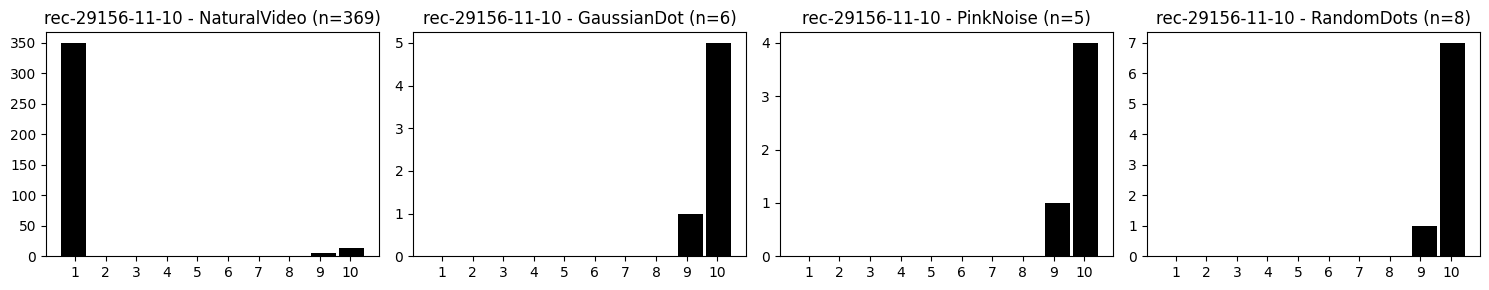

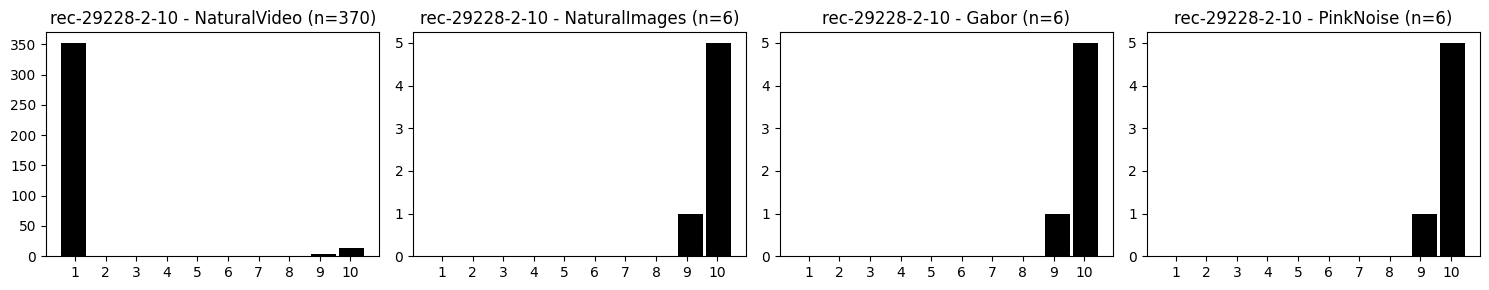

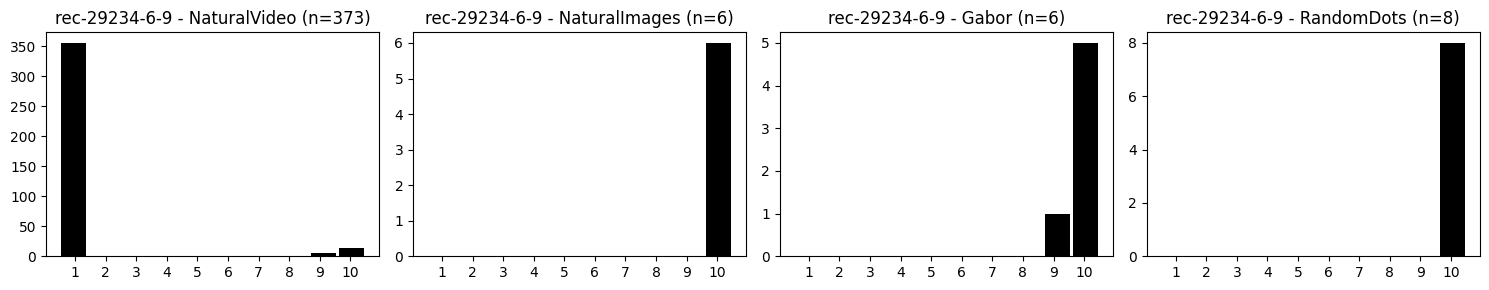

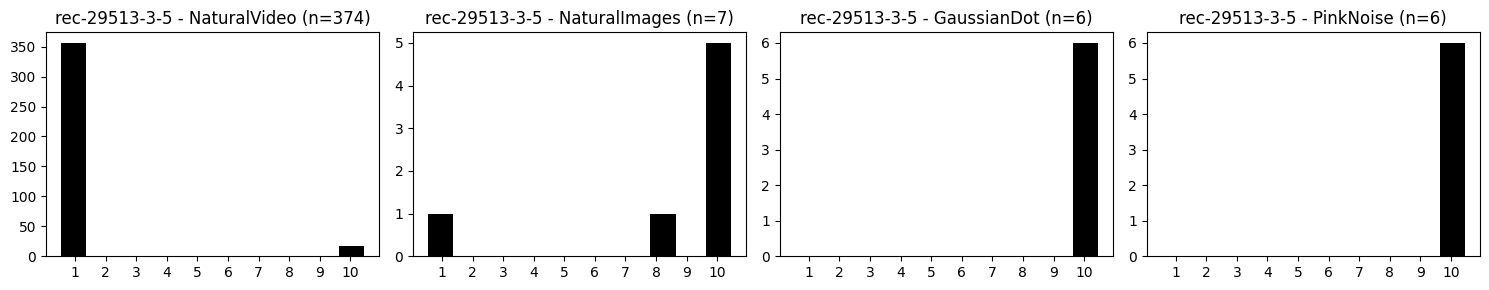

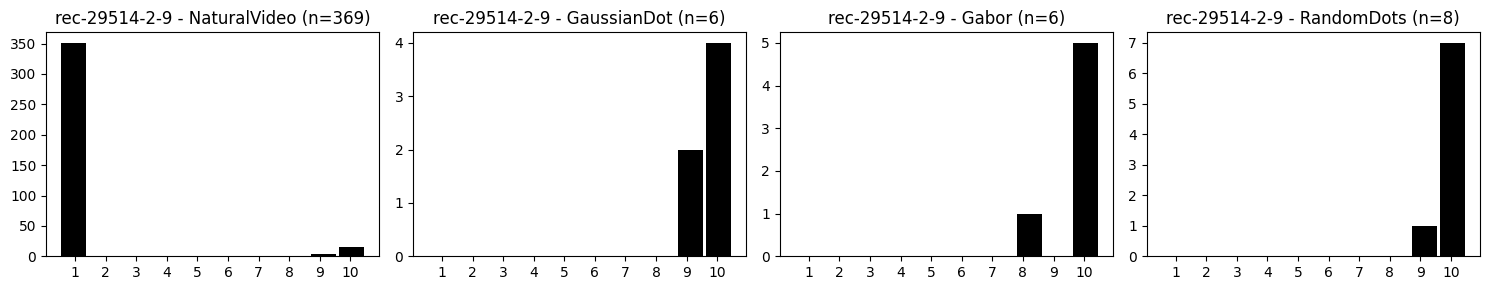

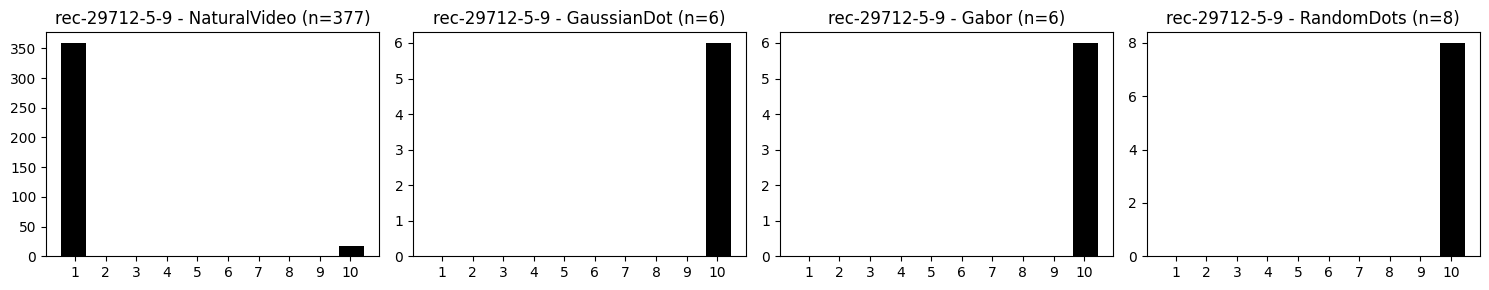

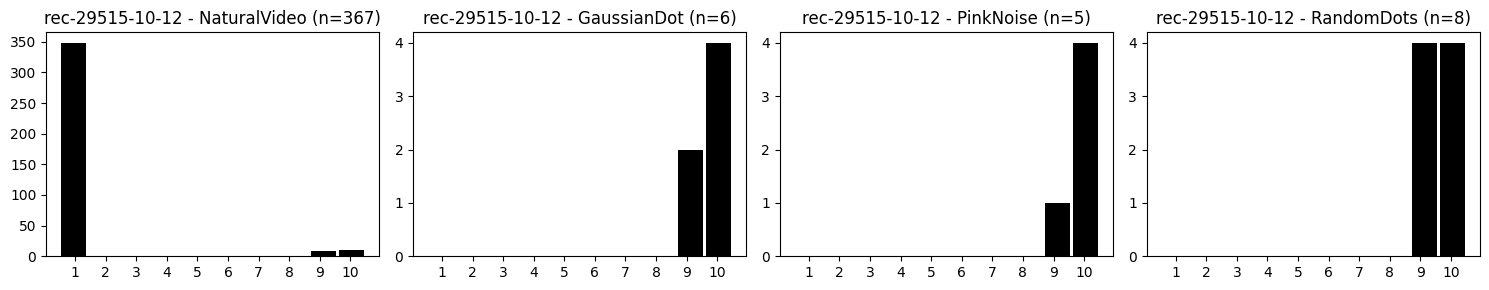

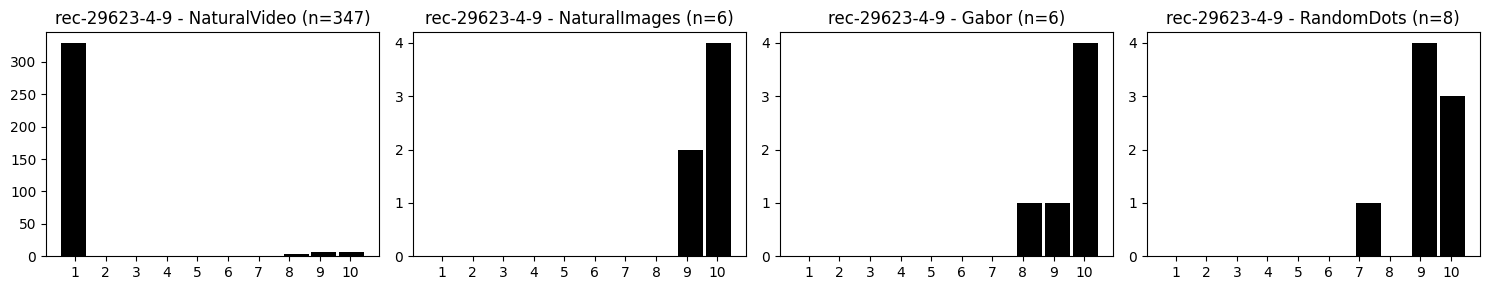

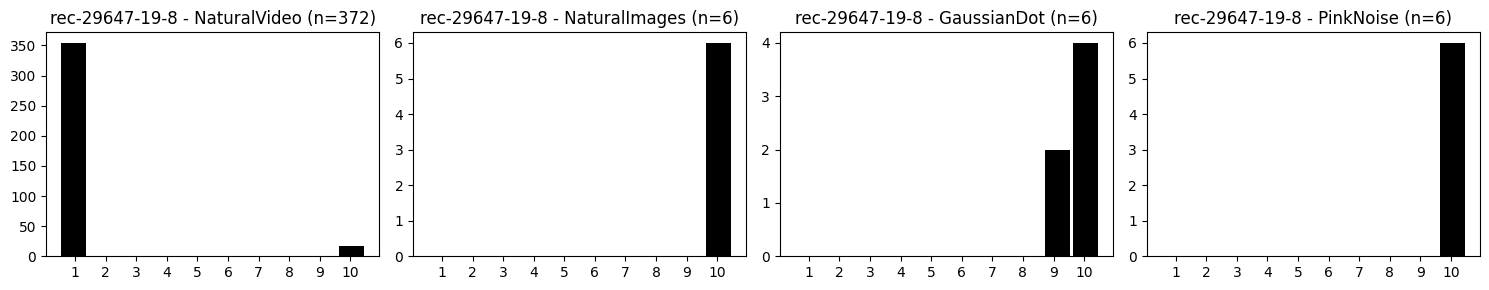

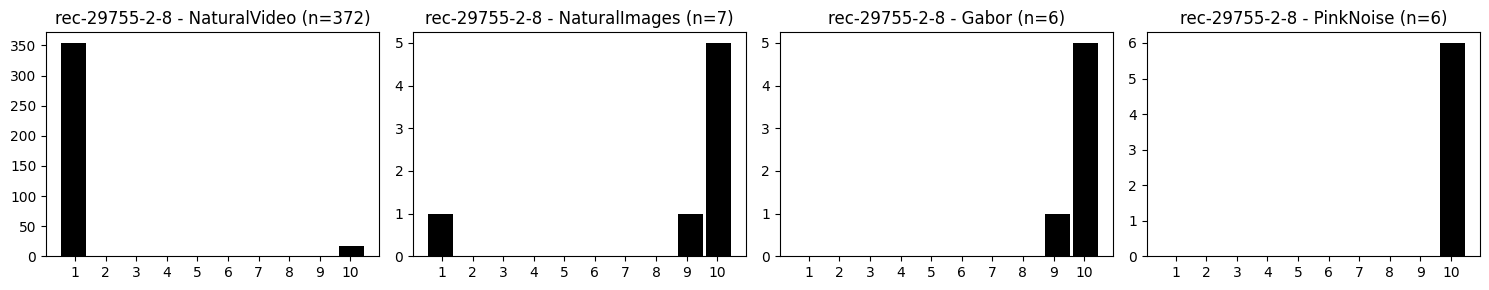

In [ ]:
ordered_labels = ['NaturalVideo','NaturalImages','GaussianDot','Gabor','PinkNoise','RandomDots']

# for each recording and label find the number of replicates of each video
counts = ds.count_videos_across(['recording','label','ID'])

for rec in ds.recording:
    all_trials_df_rec = ds.filter_trials(recording=rec)
    labels = set(all_trials_df_rec['label'].to_list())
    labels = [x for x in ordered_labels if x in labels]
        
    fig, ax =plt.subplots(nrows=1, ncols=4, figsize=(15, 3))
    for i, label in enumerate(labels):
        d = counts[(counts['recording']==rec) & (counts['label']==label)]['count'].to_numpy()
        h = ax[i].hist(d, range=(.5, 10.5), bins=11, color='k',rwidth=0.9)
        ax[i].set_xticks(np.arange(1,11))
        ax[i].set_title(f"{mapping[rec]} - {label} (n={len(d)})")

    fig.tight_layout()
    fig.savefig(Path(repo_root, 'figures', f'count-video-duplicates_x-label_{mapping[rec]}.png'))

### Inspect recordings with unusual number of appearances of videos

#### Recording ...29513-3-5... for NaturalImages

In recording ...29513-3-5..., one NaturalImages video appears only once.

Print repetition counts for videos classified as NaturalImages in recording ...3-5....

In [6]:
rec = 'dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce'
label = "NaturalImages"
counts[(counts['recording']==rec) & (counts['label']==label)]

,recording,label,ID,count
90,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v484546,10
103,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v089720,10
111,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v360898,10
113,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v683710,10
122,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v062658,10
184,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,8
1361,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v565001,1


Print a DataFrame with trials for the video ID that appears 8 times.

In [7]:
ds.filter_trials(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', label="NaturalImages", ID='v874315')

,recording,label,ID,trial,trial_type,valid_frames,valid_trial
2344,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,702,live_test_main,305,True
2455,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,719,train,305,True
2648,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,689,train,305,True
2690,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,685,final_test_bonus,306,True
2830,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,693,live_test_bonus,306,True
2832,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,705,live_test_bonus,306,True
2840,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,717,live_test_bonus,305,True
2847,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,681,live_test_bonus,305,True


Print a DataFrame with trials for the video ID that appears only once.

In [8]:
ds.filter_trials(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', label="NaturalImages", ID='v565001')

,recording,label,ID,trial,trial_type,valid_frames,valid_trial
2420,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v565001,668,train,403,False


The video that appears once is labeled as an invalid trial; it corresponds to the video with bad segments.

Load the video that appears 8 times and the one that appears once (the invalid trial).

For both videos, plot frame-to-frame changes and display sample frames.

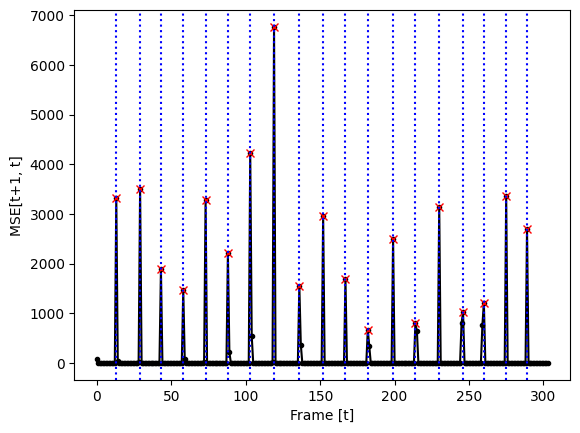

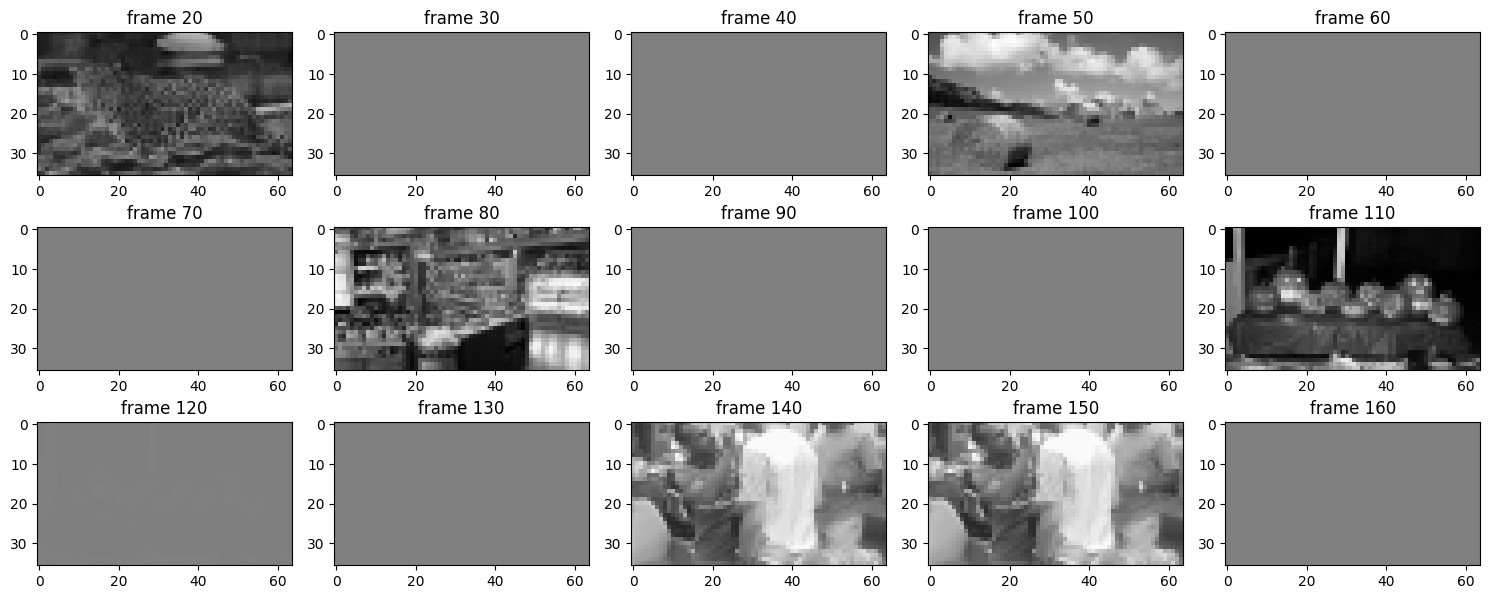

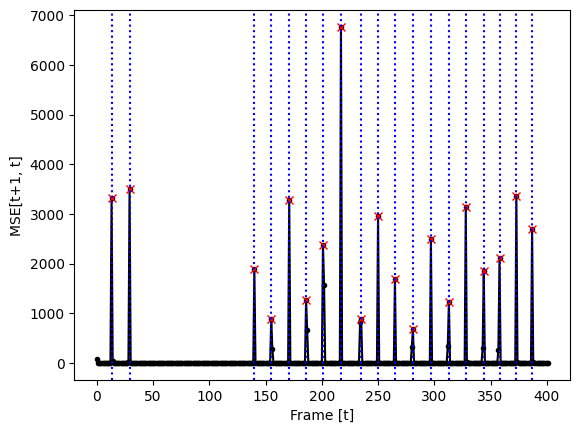

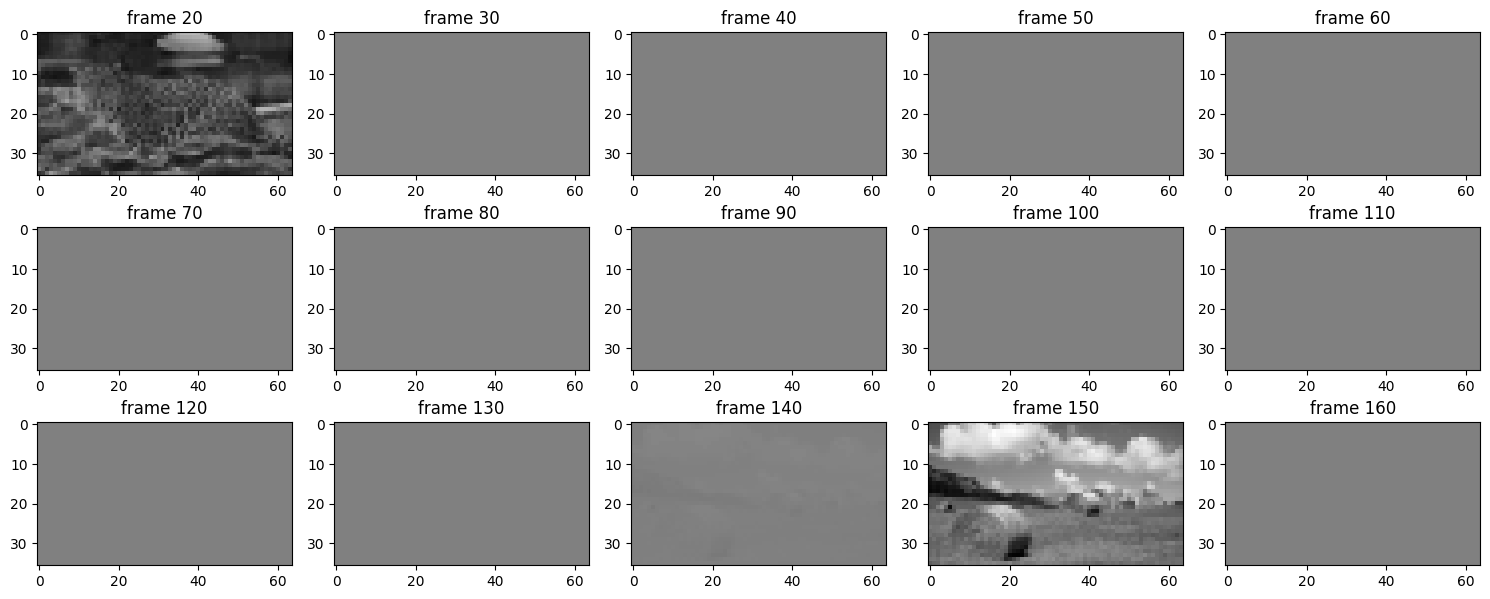

In [27]:
# load
video_i = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='702')
video_j = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='668')
# plot
frames = np.arange(20,170,10)
_ = video_i.plot_changes()
_ = video_i.plot_frames(frames)
_ = video_j.plot_changes()
_ = video_j.plot_frames(frames)

#### Recording 29755-2-8 for NaturalImages

In recording 29755-2-8, one NaturalImages video appears only once.

Print repetition counts for videos classified as NaturalImages in recording ...3-5....

In [19]:
rec = 'dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20'
label = "NaturalImages"
counts[(counts['recording']==rec) & (counts['label']==label)]

,recording,label,ID,count
273,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v827550,10
280,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v926353,10
282,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v508437,10
289,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v685530,10
296,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v693888,10
359,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v230207,9
3605,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v731584,1


Print a DataFrame with trials for the video ID that appears 9 times.

In [20]:
ds.filter_trials(recording='dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20', label="NaturalImages", ID='v230207')

,recording,label,ID,trial,trial_type,valid_frames,valid_trial
6503,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v230207,363,final_test_main,319,True
6519,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v230207,173,final_test_main,319,True
6625,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v230207,52,train,319,True
6678,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v230207,603,final_test_bonus,319,True
6784,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v230207,607,final_test_bonus,319,True
6790,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v230207,250,train,319,True
6923,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v230207,323,final_test_bonus,319,True
7041,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v230207,561,oracle,319,True
7127,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v230207,35,train,319,True


Print a DataFrame with trials for the video ID that appears only once.

In [21]:
ds.filter_trials(recording='dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20', label="NaturalImages", ID='v731584')

,recording,label,ID,trial,trial_type,valid_frames,valid_trial
6591,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v731584,156,live_test_main,414,False


The video that appears once is labeled as an invalid trial; it corresponds to the video with bad segments.

Load the video that appears 9 times and the one that appears once (the invalid trial).

For both videos, plot frame-to-frame changes and display sample frames.

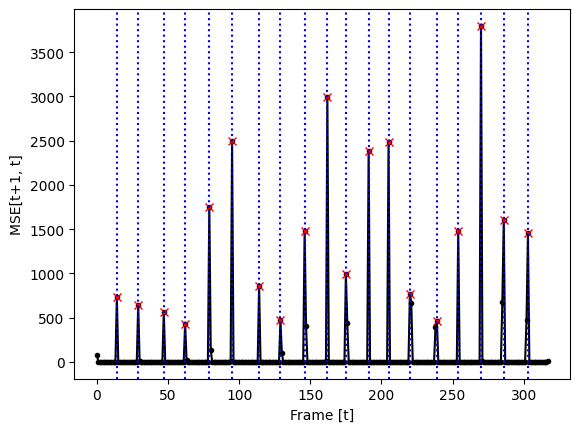

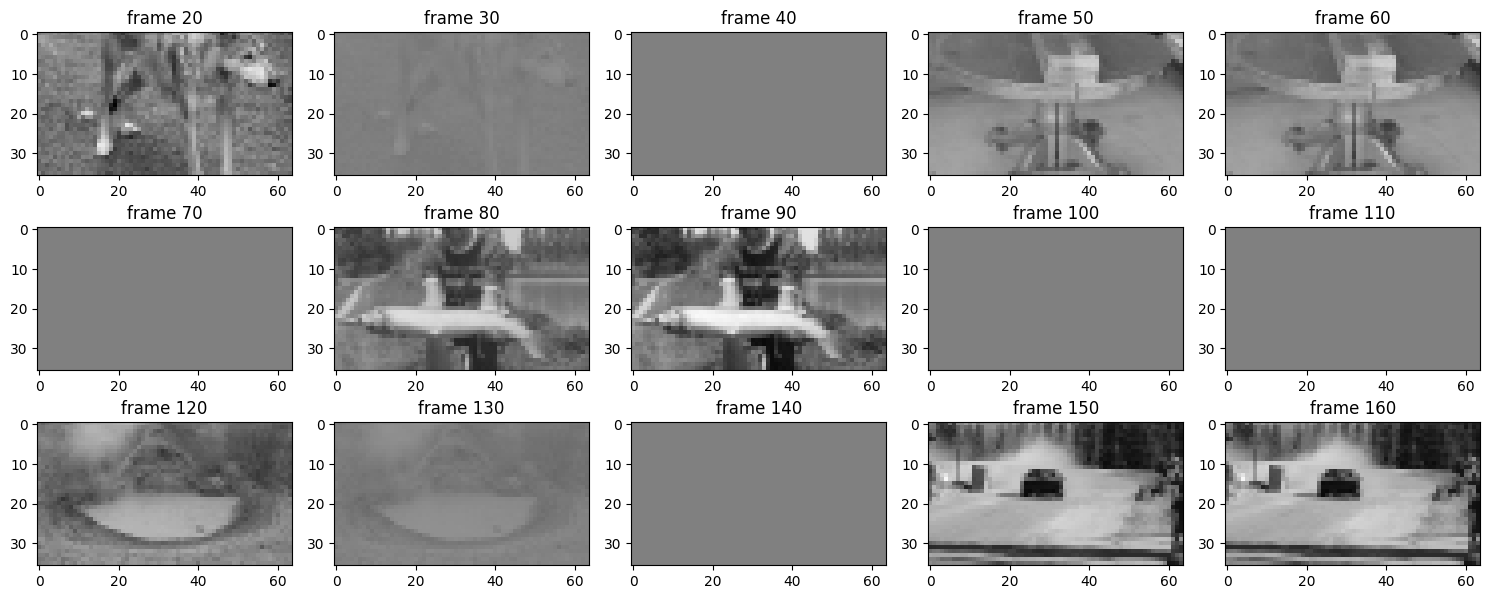

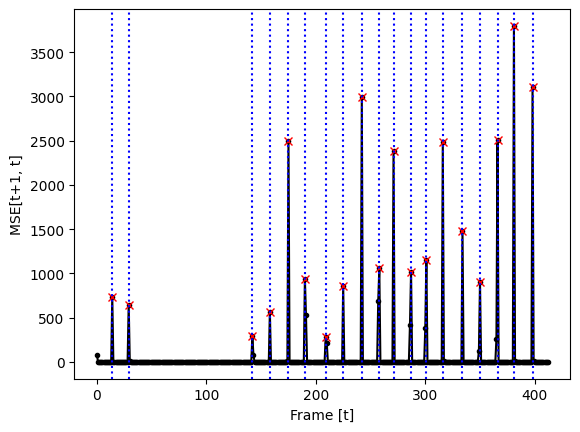

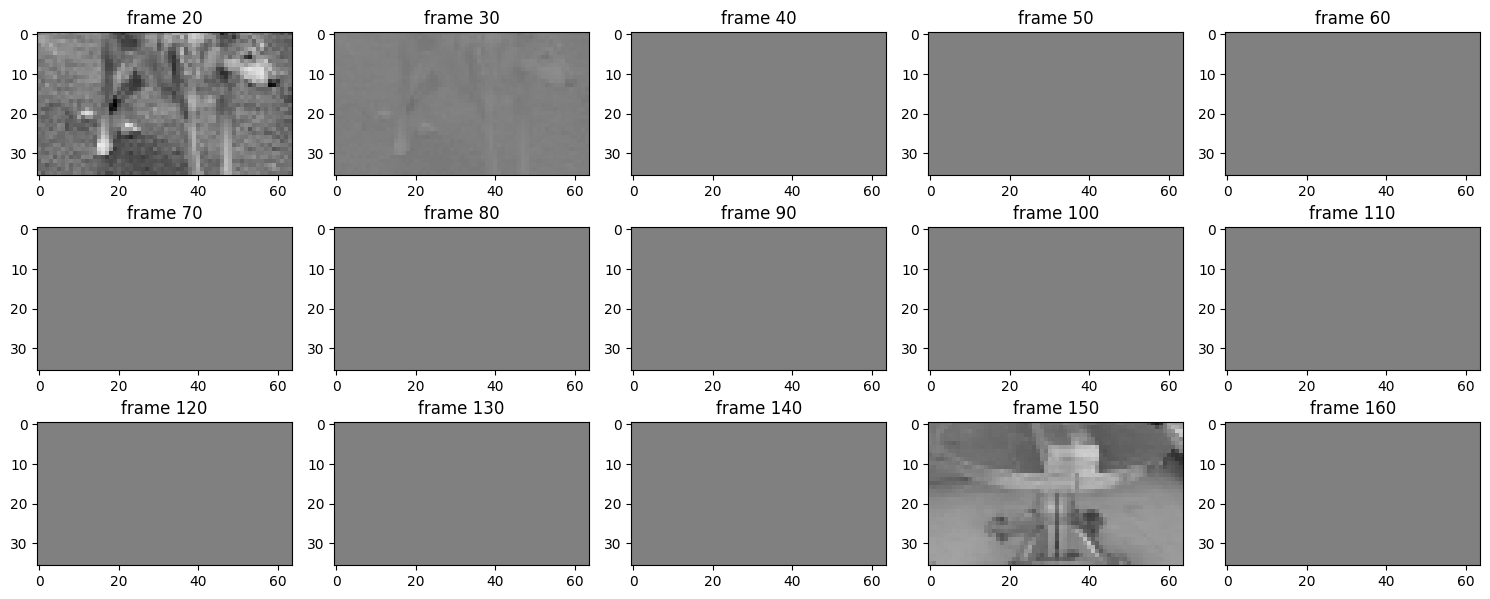

In [26]:
# load
video_i = ds.load_video_by_trial(recording='dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='363')
video_j = ds.load_video_by_trial(recording='dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='156')
# plot
frames = np.arange(20, 170, 10)
_ = video_i.plot_changes()
_ = video_i.plot_frames(frames)
_ = video_j.plot_changes()
_ = video_j.plot_frames(frames)

### Check two instances of a repeated video

Print a DataFrame with all trials for one video ID.

In [11]:
ds.filter_trials(recording=all_recording_folders[1], ID="v467193")

,recording,label,ID,trial,trial_type,valid_frames,valid_trial
736,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,NaturalVideo,v467193,180,train,300,True
835,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,NaturalVideo,v467193,461,final_test_bonus,300,True
872,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,NaturalVideo,v467193,141,live_test_bonus,300,True
933,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,NaturalVideo,v467193,191,train,300,True
1123,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,NaturalVideo,v467193,338,live_test_bonus,300,True
1145,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,NaturalVideo,v467193,4,final_test_main,300,True
1194,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,NaturalVideo,v467193,263,final_test_main,300,True
1276,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,NaturalVideo,v467193,526,train,300,True
1390,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,NaturalVideo,v467193,19,final_test_bonus,300,True
1418,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,NaturalVideo,v467193,198,final_test_bonus,300,True


Load two trials with the same video ID.

In [12]:
rec = 'dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce'
video_i = ds.load_video_by_trial(recording=rec, trial='526')
video_j = ds.load_video_by_trial(recording=rec, trial='4')

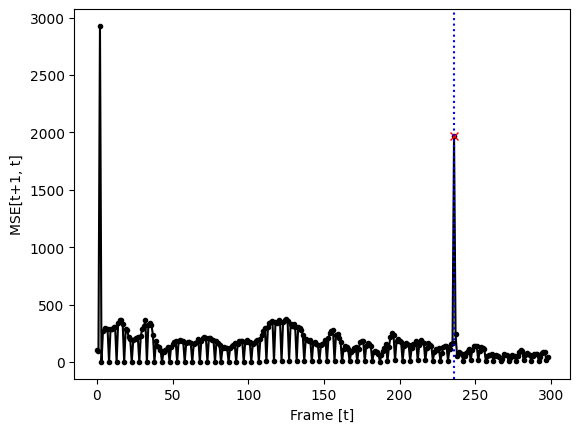

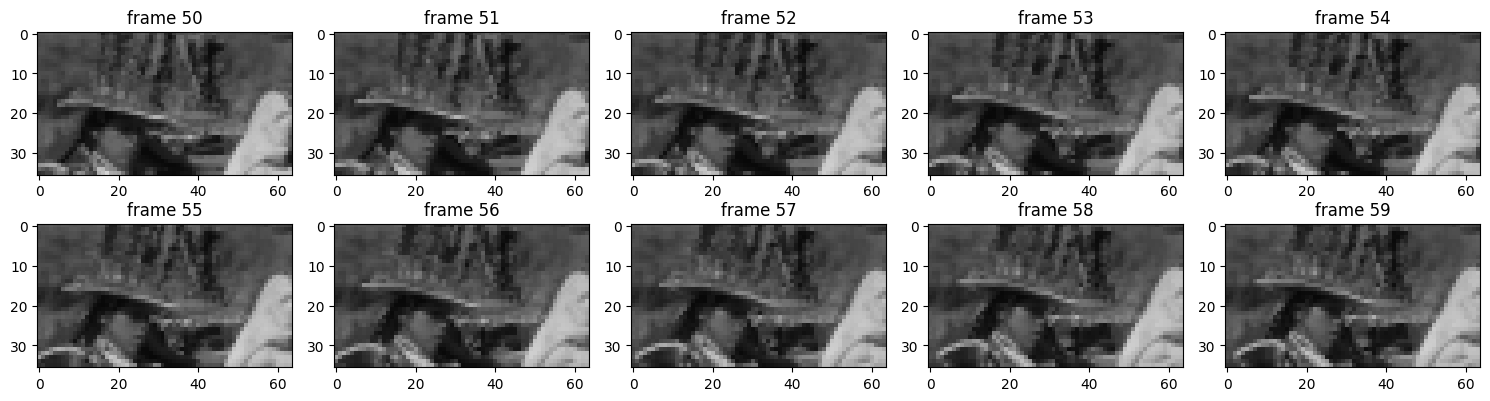

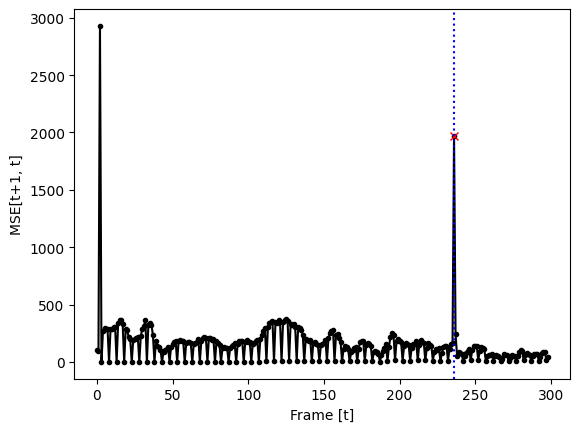

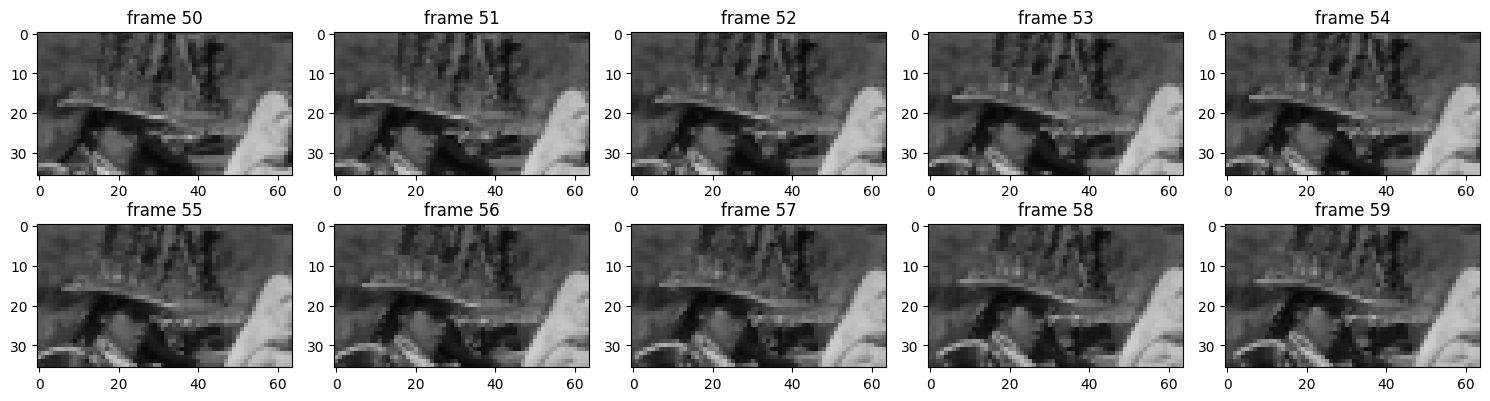

In [13]:
frames = np.arange(50,60)
_ = video_i.plot_changes()
_ = video_i.plot_frames(frames)
_ = video_j.plot_changes()
_ = video_j.plot_frames(frames)

## Video similarity

Check the distribution of dissimilarity values across labels (for one recording).

In [14]:
def plot_dissimilarity_matrix(dissimilarity):
    fig, ax =plt.subplots(nrows=1, ncols=1, figsize=(6, 6))
    vmax = np.max(dissimilarity[np.isnan(dissimilarity)==False].flatten())
    im_diss = ax.imshow(dissimilarity, cmap='Reds_r', vmin=0, vmax=vmax, aspect='equal')
    ax.set_aspect('equal', adjustable='box')
    bcol = fig.colorbar(im_diss, ax=ax)
    bcol.set_label("dissimilarity", rotation=270, labelpad=15)
    ax.set_xlabel("video index")
    ax.set_ylabel("video index")
    return fig, ax

In [15]:
def plot_dissimilarity_hist(dissimilarity,bins=100, range=None):
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 6))
    if range is None:
        range = (0, np.max(dissimilarity[np.isnan(dissimilarity)==False].flatten()))
    h = ax.hist(dissimilarity.flatten(), range=range, bins=bins, color='k', rwidth=1)
    ax.set_xlabel("dissimilarity")
    ax.set_ylabel("video counts")
    return fig, ax

### NaturalVideo

In [16]:
recording_folder = all_recording_folders[1]
thelabel = 'NaturalVideo'
dissimilarity, trials_df = ds.compute_dissimilarity_videos(recording=recording_folder, label=thelabel, check_edges_first=False)

Computing dissimilarity: 100%|██████████| 527/527 [12:29<00:00,  1.42s/it]  


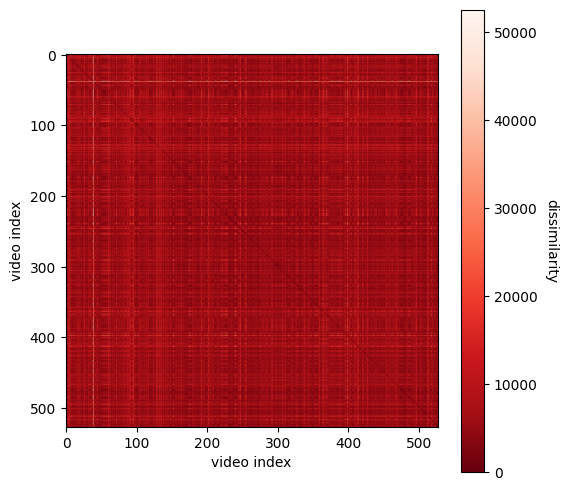

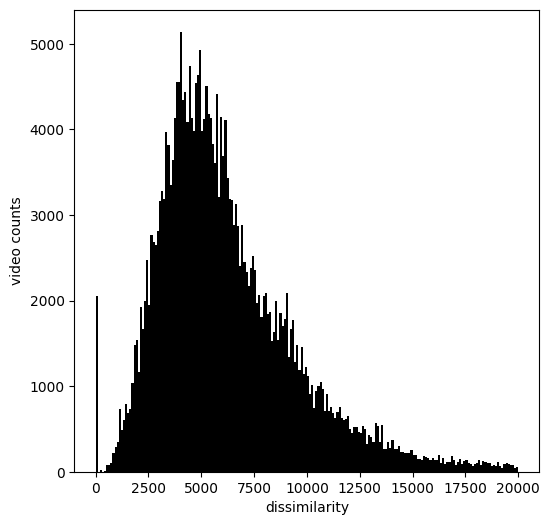

In [17]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_{mapping[recording_folder]}.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=200, range=(0, 20000))
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_{mapping[recording_folder]}.png"), dpi=300)

### Gabor

In [18]:
recording_folder = all_recording_folders[1]
thelabel = 'Gabor'
dissimilarity, trials_df = ds.compute_dissimilarity_videos(recording=recording_folder, label=thelabel, check_edges_first=False)

Computing dissimilarity: 100%|██████████| 59/59 [00:07<00:00,  7.97it/s]


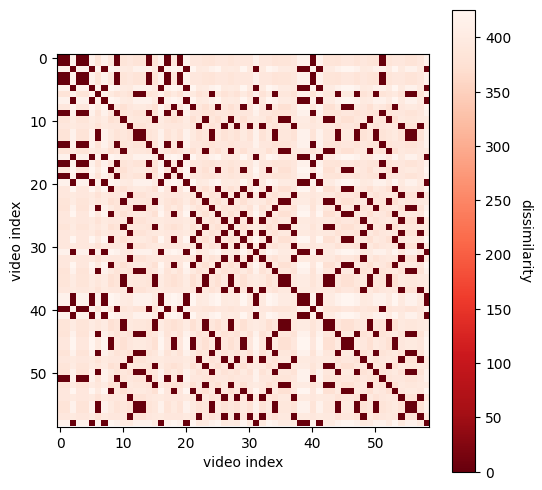

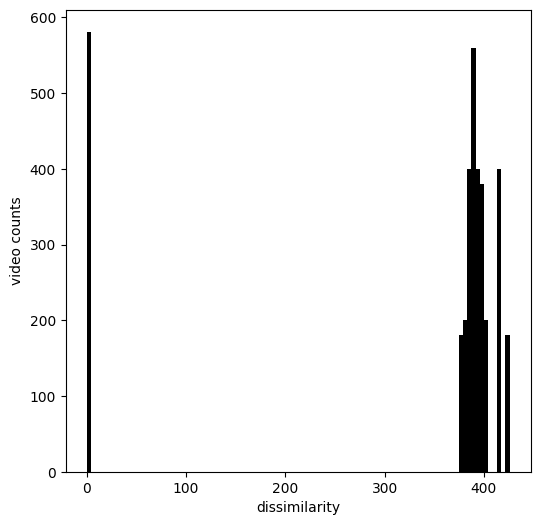

In [19]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_rec-{mapping[recording_folder]}.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=100, range=None)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_rec-{mapping[recording_folder]}.png"), dpi=300)


### NaturalImages

In [20]:
recording_folder = all_recording_folders[1]
thelabel = 'NaturalImages'
dissimilarity, trials_df = ds.compute_dissimilarity_videos(recording=recording_folder, label=thelabel, check_edges_first=False)

Computing dissimilarity: 100%|██████████| 59/59 [00:08<00:00,  7.12it/s]


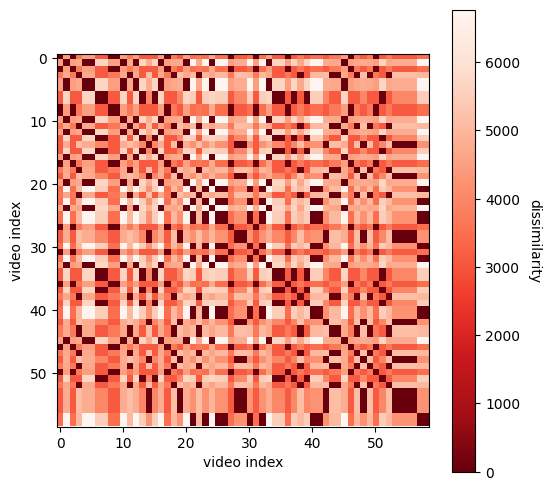

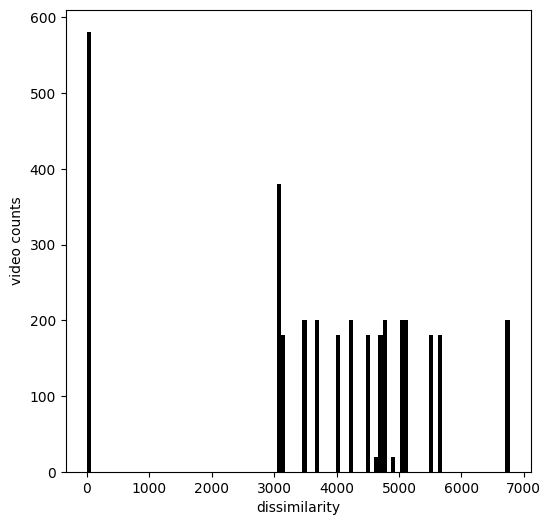

In [21]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_{mapping[recording_folder]}.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=100, range=None)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_{mapping[recording_folder]}.png"), dpi=300)


### PinkNoise

In [22]:
recording_folder = all_recording_folders[1]
thelabel = 'PinkNoise'
dissimilarity, trials_df = ds.compute_dissimilarity_videos(recording=recording_folder, label=thelabel, check_edges_first=False)

Computing dissimilarity: 100%|██████████| 59/59 [00:07<00:00,  8.03it/s]


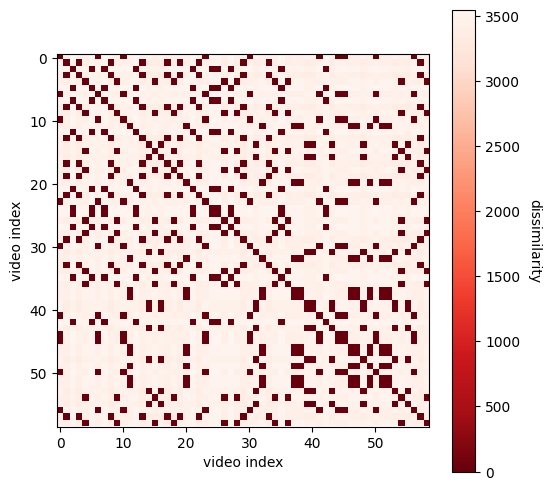

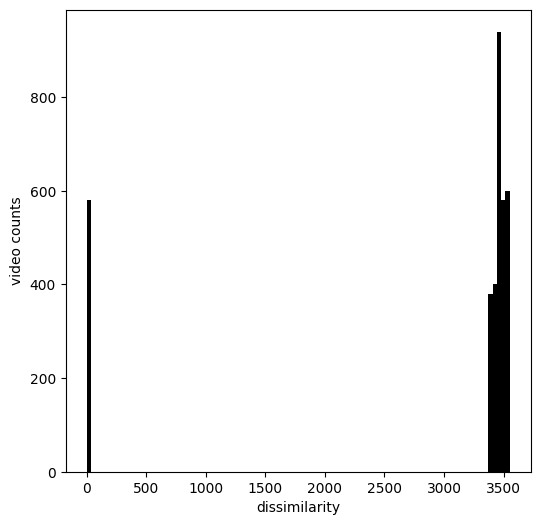

In [23]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_{mapping[recording_folder][3:-3]}.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=100, range=None)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_{mapping[recording_folder][3:-3]}.png"), dpi=300)


### RandomDots

In [24]:
recording_folder = all_recording_folders[0]
thelabel = 'RandomDots'
dissimilarity, trials_df = ds.compute_dissimilarity_videos(recording=recording_folder, label=thelabel, check_edges_first=False)

Computing dissimilarity: 100%|██████████| 79/79 [00:10<00:00,  7.61it/s]


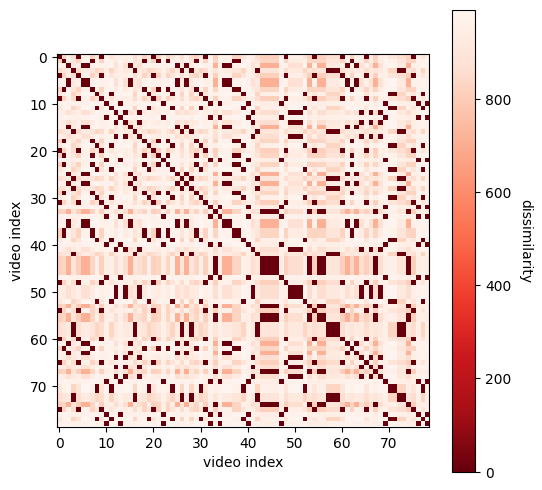

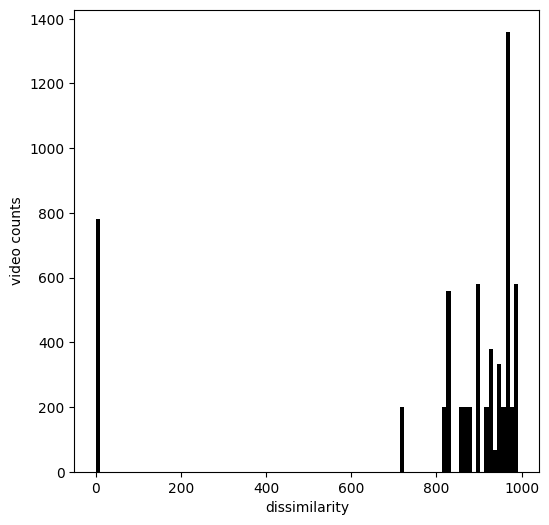

In [25]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_{mapping[recording_folder][3:-3]}.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=100, range=None)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_{mapping[recording_folder][3:-3]}.png"), dpi=300)


### GaussianDot

In [26]:
recording_folder = all_recording_folders[0]
thelabel = 'GaussianDot'
dissimilarity, trials_df = ds.compute_dissimilarity_videos(recording=recording_folder, label=thelabel, check_edges_first=False)

Computing dissimilarity: 100%|██████████| 59/59 [00:08<00:00,  6.73it/s]


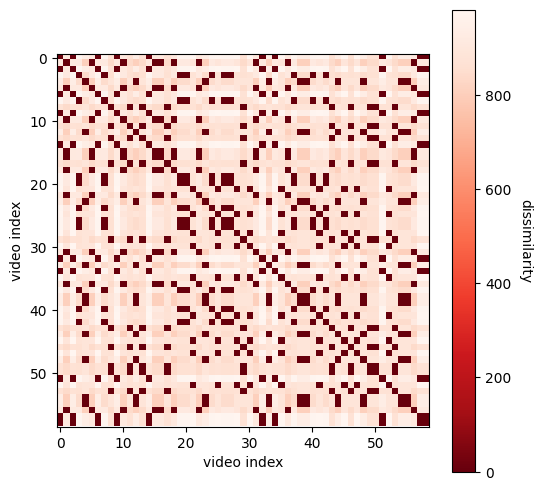

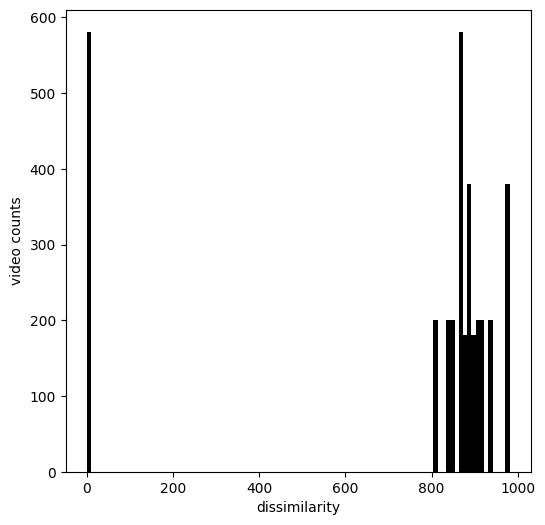

In [27]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_{mapping[recording_folder][3:-3]}.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=100, range=None)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_{mapping[recording_folder][3:-3]}.png"), dpi=300)
